# Train and sample a conditional DDPM

Generative diffusion corrupts examples with Gaussian noise and learns to predict that noise. It is different from heat smoothing. Our reverse sampler conditions on sensor backprojection and includes heuristic measurement correction. This is a teaching conditional generator, not an exact noisy posterior sampler.

**Objective:** train noise prediction and inspect multiple possible fields and their spread.

In [1]:
from pathlib import Path
import os
if Path.cwd().name == 'tutorials': os.chdir('..')
import numpy as np
import matplotlib.pyplot as plt
from fieldlab import Grid, points, lines, footprints, projections, combine
from fieldlab.fields import simulate, sensor_layout
from fieldlab.operators import observe
from fieldlab.models import idw, tikhonov, gaussian_process, total_variation, heat_reconstruction


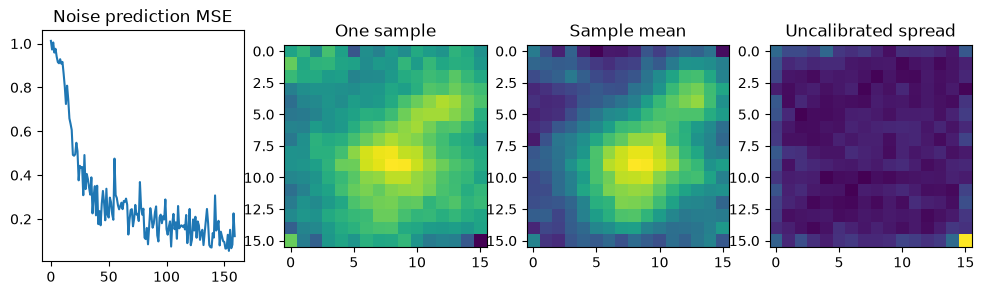

Mean RMSE: 0.09828097747453318


In [2]:
from fieldlab.neural import ConditionalDiffusion
grid=Grid((16,16)); A,_=sensor_layout(grid,seed=7)
ddpm=ConditionalDiffusion(timesteps=30)
loss=ddpm.train(grid,A,steps=160,count=96,seed=2000)
truth=simulate(grid,9100); y=observe(A,truth,.03,9101)
r,draws=ddpm.reconstruct(grid,A,y,samples=6,seed=3000)
fig,axes=plt.subplots(1,4,figsize=(12,3))
axes[0].plot(loss); axes[0].set_title('Noise prediction MSE')
for ax,name,f in zip(axes[1:],['One sample','Sample mean','Uncalibrated spread'],[draws[0],r.mean,r.std]): ax.imshow(f); ax.set_title(name)
plt.show()
assert np.isfinite(draws).all()
print('Mean RMSE:',np.sqrt(np.mean((r.mean-truth)**2)))


**Exercise:** compare guidance strengths 0, .05, and .5, keeping the seed fixed. Does fitting noisy data improve field error? Increase training to 1000 steps and evaluate several independent seeds. Explain why sample spread is not automatically a credible interval.

See [theory notes](../docs/theory.md) for assumptions and equations.